# 🎵 Music Instrument Classification
**Advanced Technology Integration · Universidad de Jaén · 2026**

Based on: Seungheondoh (2019) · Kadandale (2018) — improved pipeline

---

## ✅ How to run this notebook

### Option A — Your groupmate's laptop (RECOMMENDED — no uploading needed)
1. Open a terminal and run: `pip install jupyter librosa scikit-learn seaborn pyyaml tqdm joblib soundfile`
2. Then run: `jupyter notebook`
3. Open this file in Jupyter
4. In **Cell 2**, set `RUN_MODE = 'local'` and set `MEDLEYDB_PATH` to the folder on your hard drive

### Option B — Google Colab (only if you upload a small subset to Drive)
1. Upload only the stems you need (~5–10 GB) to Google Drive
2. Open this file in Colab: File → Upload notebook
3. In **Cell 2**, set `RUN_MODE = 'colab'` and set `MEDLEYDB_PATH` to your Drive path

### Run cells one by one in order — do NOT click Run All


---
## CELL 1 — Install Libraries
Run this first. Works for both local Jupyter and Google Colab.


In [2]:
# Install all required libraries
# This works on both local Jupyter and Google Colab
import subprocess, sys

libs = [
    'librosa==0.10.1',
    'scikit-learn',
    'seaborn',
    'pyyaml',
    'tqdm',
    'joblib',
    'soundfile',
    'matplotlib',
    'pandas',
    'numpy',
]

for lib in libs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

import librosa
import librosa.display
import numpy as np
import pandas as pd
import os
import yaml
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.base import clone

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

import joblib
from tqdm import tqdm
from collections import Counter
from IPython.display import Audio, display

print('=' * 55)
print('  All libraries ready ✓')
print(f'  librosa version: {librosa.__version__}')
print('=' * 55)


  All libraries ready ✓
  librosa version: 0.10.1


---
## CELL 2 — Setup Paths ⚠️ EDIT THIS CELL
**This is the only cell you need to edit.**
Set `RUN_MODE` and `MEDLEYDB_PATH` for your situation.


In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EDIT THESE TWO LINES — EVERYTHING ELSE LEAVE AS-IS    ║
# ╚══════════════════════════════════════════════════════════╝
RUN_MODE = 'local' 
MEDLEYDB_PATH = r'C:\MDB\download_2026-06-03_18-52-53\MedleyDB'


# ══════════════════════════════════════════════════════════════
# DO NOT EDIT BELOW THIS LINE
# ══════════════════════════════════════════════════════════════

# Mount Google Drive only if using Colab
if RUN_MODE == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/MIC_Project_Output/'
    print('Google Drive mounted ✓')
else:
    # Local mode: save output next to the notebook
    SAVE_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                             'MIC_Project_Output')
    print('Running in LOCAL mode ✓')
    print(f'Output will be saved to: {SAVE_PATH}')

os.makedirs(SAVE_PATH, exist_ok=True)

# ── Audio settings (confirmed best from Kadandale 2018) ───────────────────
SR                = 22050
N_FFT             = 2048
HOP_LEN           = 512
MFCC_DIM          = 13
N_MELS            = 128
DURATION          = 5.0
SILENCE_THRESHOLD = 0.01

# ── Instrument classes ─────────────────────────────────────────────────────
# These are the most common instruments in MedleyDB.
# Run Cell 4 first to see the actual names in your dataset.
INSTRUMENTS = [
    'clean electric guitar',
    'acoustic guitar',
    'piano',
    'drum set',
    'electric bass',
    'violin',
    'male singer',
    'female singer',
    'trumpet',
    'tenor saxophone',
]

# ── File paths for saving features ────────────────────────────────────────
X_SAVE = os.path.join(SAVE_PATH, 'X_features.npy')
Y_SAVE = os.path.join(SAVE_PATH, 'y_labels.npy')
G_SAVE = os.path.join(SAVE_PATH, 'groups_songs.npy')

print()
print(f'  MedleyDB path : {MEDLEYDB_PATH}')
print(f'  Save path     : {SAVE_PATH}')
print(f'  Mode          : {RUN_MODE}')
print(f'  SR            : {SR} Hz')
print(f'  MFCC coeff    : {MFCC_DIM}')
print(f'  Mel bands     : {N_MELS}')
print(f'  Classes       : {len(INSTRUMENTS)}')
for inst in INSTRUMENTS:
    print(f'    - {inst}')
print()

# Check MedleyDB path exists
if os.path.exists(MEDLEYDB_PATH):
    print(f'  MedleyDB folder found ✓')
else:
    print(f'  ✗ ERROR: MedleyDB not found at: {MEDLEYDB_PATH}')
    print(f'  → Fix MEDLEYDB_PATH above and re-run this cell')


Running in LOCAL mode ✓
Output will be saved to: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output

  MedleyDB path : C:\MDB\download_2026-06-03_18-52-53\MedleyDB
  Save path     : C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output
  Mode          : local
  SR            : 22050 Hz
  MFCC coeff    : 13
  Mel bands     : 128
  Classes       : 10
    - clean electric guitar
    - acoustic guitar
    - piano
    - drum set
    - electric bass
    - violin
    - male singer
    - female singer
    - trumpet
    - tenor saxophone

  MedleyDB folder found ✓


---
## CELL 3 — Verify MedleyDB Structure
Confirms Colab/Jupyter can see your files. If it fails, fix `MEDLEYDB_PATH` in Cell 2.


In [4]:
def verify_medleydb(path):
    print(f'Checking MedleyDB at: {path}\n')
    if not os.path.exists(path):
        print(f'  ERROR: Folder not found at {path}')
        print('  → Fix MEDLEYDB_PATH in Cell 2')
        return False
    audio_path = os.path.join(path, 'Audio')
    if not os.path.exists(audio_path):
        # Some MedleyDB versions have audio directly in root
        print(f'  No Audio/ subfolder — checking root directly...')
        songs = [s for s in os.listdir(path)
                 if os.path.isdir(os.path.join(path, s))]
        print(f'  Subfolders found: {songs[:5]}')
        print('  → Your MedleyDB should have: medleydb/Audio/SongName/...')
        print('  → Or: medleydb/SongName/STEMS/... (some versions)')
        return False
    songs = [s for s in os.listdir(audio_path)
             if os.path.isdir(os.path.join(audio_path, s))]
    print(f'  Songs found      : {len(songs)}')
    if not songs:
        print('  ERROR: No song folders found inside Audio/')
        return False
    first_song = sorted(songs)[0]
    first_path = os.path.join(audio_path, first_song)
    yaml_path  = os.path.join(first_path, f'{first_song}_METADATA.yaml')
    stems_path = os.path.join(first_path, 'STEMS')
    if not os.path.exists(stems_path):
        stems_path = os.path.join(first_path, f'{first_song}_STEMS')
    print(f'  First song       : {first_song}')
    print(f'  METADATA.yaml    : {"✓ Found" if os.path.exists(yaml_path) else "✗ NOT FOUND"}')
    print(f'  STEMS folder     : {"✓ Found" if os.path.exists(stems_path) else "✗ NOT FOUND"}')
    if os.path.exists(stems_path):
        wavs = [f for f in os.listdir(stems_path) if f.endswith('.wav')]
        print(f'  WAV stems found  : {len(wavs)}')
        if wavs:
            print(f'  Example stem     : {wavs[0]}')
    if os.path.exists(yaml_path):
        with open(yaml_path) as f:
            meta = yaml.safe_load(f)
        print(f'\n  Instruments in first song:')
        for sid, info in list(meta['stems'].items())[:6]:
            print(f'    {sid}: {info["instrument"]}')
        if len(meta['stems']) > 6:
            print(f'    ... and {len(meta["stems"])-6} more')
    print('\n  Structure OK ✓')
    return True

verify_medleydb(MEDLEYDB_PATH)


Checking MedleyDB at: C:\MDB\download_2026-06-03_18-52-53\MedleyDB

  Songs found      : 122
  First song       : AClassicEducation_NightOwl
  METADATA.yaml    : ✓ Found
  STEMS folder     : ✓ Found
  WAV stems found  : 13
  Example stem     : AClassicEducation_NightOwl_STEM_01.wav

  Instruments in first song:
    S01: electric bass
    S02: drum set
    S03: distorted electric guitar
    S04: distorted electric guitar
    S05: clean electric guitar
    S06: distorted electric guitar
    ... and 7 more

  Structure OK ✓


True

---
## CELL 4 — Explore Dataset
Shows all instrument names in MedleyDB. **Run this to confirm the exact instrument names** before extracting features.


Reading MedleyDB metadata...
  Songs loaded: 122

ALL instrument names in MedleyDB (copy exact names to INSTRUMENTS list in Cell 2):
-------------------------------------------------------
  'drum set',                                     66  █████████████
  'electric bass',                                     63  ████████████
  'clean electric guitar',                                     57  ███████████
  'synthesizer',                                     47  █████████
  'male singer',                                     44  ████████
  'piano',                                     43  ████████
  'fx/processed sound',                                     41  ████████
  'distorted electric guitar',                                     33  ██████
  'vocalists',                                     33  ██████
  'female singer',                                     32  ██████
  'violin',                                     27  █████
  'acoustic guitar',                                     26  █

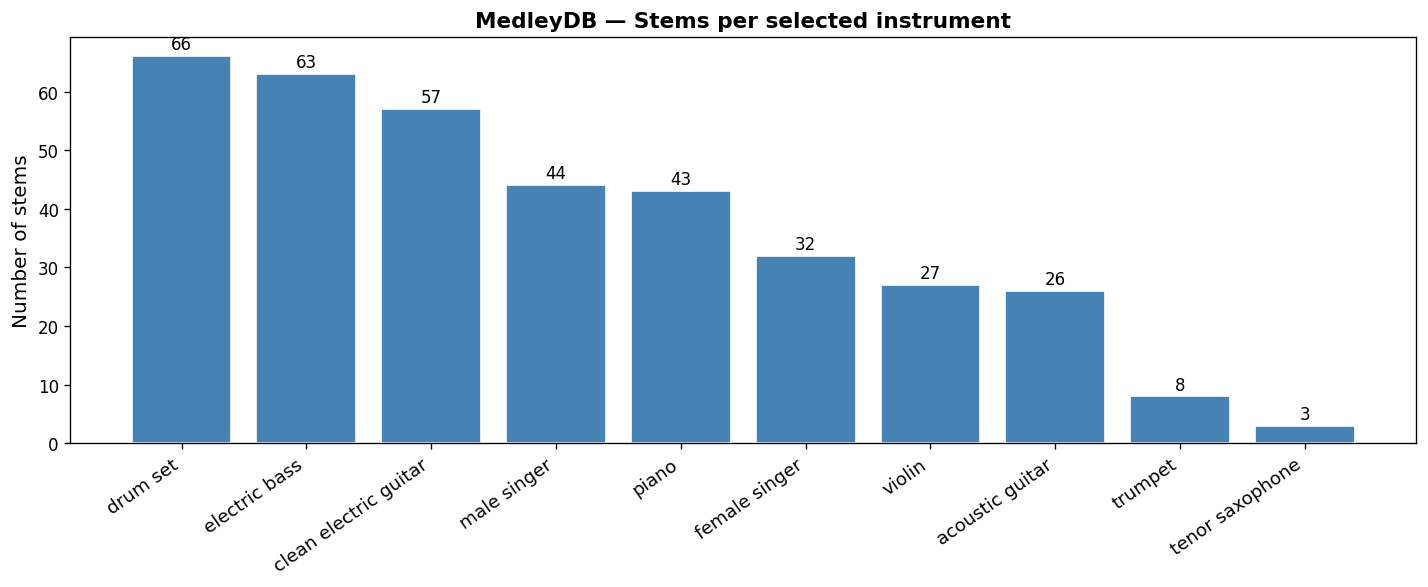

Chart saved ✓ — insert into your report Section 3.2


In [5]:
def read_medleydb_metadata(medleydb_path):
    '''
    Reads all MedleyDB YAML metadata files.
    Returns dict: {song_name: {stem_id: instrument_name}}
    Source: adapted from vskadandale data_prep.py (Python 3)
    '''
    audio_path = os.path.join(medleydb_path, 'Audio')
    metadata = {}
    songs = [s for s in os.listdir(audio_path)
             if os.path.isdir(os.path.join(audio_path, s))]
    for song_name in sorted(songs):
        yaml_file = os.path.join(audio_path, song_name,
                                 f'{song_name}_METADATA.yaml')
        if not os.path.exists(yaml_file):
            continue
        try:
            with open(yaml_file, 'r') as f:
                meta = yaml.safe_load(f)
            metadata[song_name] = {
                k: v['instrument'] for k, v in meta['stems'].items()
            }
        except Exception as e:
            print(f'  Warning: {yaml_file}: {e}')
    return metadata

print('Reading MedleyDB metadata...')
metadata = read_medleydb_metadata(MEDLEYDB_PATH)
print(f'  Songs loaded: {len(metadata)}\n')

# Count all instruments
all_counts = Counter()
for song, stems in metadata.items():
    for sid, inst in stems.items():
        all_counts[inst] += 1

print('ALL instrument names in MedleyDB (copy exact names to INSTRUMENTS list in Cell 2):')
print('-' * 55)
for inst, cnt in all_counts.most_common():
    bar = '█' * (cnt // 5)
    print(f"  '{inst}'{',' if inst != list(all_counts.keys())[-1] else ' ':<35} {cnt:>4}  {bar}")
print(f'\nTotal unique instruments: {len(all_counts)}')
print(f'Total stems             : {sum(all_counts.values())}')

# Show how many stems YOUR chosen instruments have
print('\nYour chosen instruments (from Cell 2):')
print('-' * 40)
total_chosen = 0
for inst in INSTRUMENTS:
    cnt = all_counts.get(inst, 0)
    total_chosen += cnt
    status = '✓' if cnt > 0 else '✗ NOT FOUND — check spelling'
    print(f'  {inst:<25} {cnt:>4} stems  {status}')
print(f'  {"TOTAL":<25} {total_chosen:>4} stems')

# Bar chart
chosen = {i: all_counts.get(i, 0) for i in INSTRUMENTS}
chosen = dict(sorted(chosen.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(12, 5))
bars = plt.bar(list(chosen.keys()), list(chosen.values()),
               color='steelblue', edgecolor='white')
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.ylabel('Number of stems', fontsize=12)
plt.title('MedleyDB — Stems per selected instrument', fontsize=13, fontweight='bold')
for b, v in zip(bars, chosen.values()):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓ — insert into your report Section 3.2')


---
## CELL 5 — All Functions
Defines feature extraction and plotting functions. No output expected except `Functions ready ✓`


In [5]:
# ── Silent stem filter (Kadandale 2018) ───────────────────────────────────
def is_silent(y, threshold=SILENCE_THRESHOLD):
    return np.sqrt(np.mean(y ** 2)) < threshold


# ── Feature extraction (seungheondoh 2019 — adapted + improved) ───────────
def extract_features(file_path):
    '''
    Extracts 296-dimensional feature vector from one audio stem.
    7 spectral × 2 = 14  |  13 MFCC × 2 = 26  |  128 mel × 2 = 256
    Returns list of 296 floats, or None if silent/unreadable.
    '''
    try:
        y, _ = librosa.load(file_path, sr=SR, mono=True, duration=DURATION)
        if is_silent(y):
            return None
        result = []
        for feat in [
            librosa.feature.spectral_centroid(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN),
            librosa.feature.spectral_bandwidth(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN),
            librosa.feature.spectral_contrast(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN),
            librosa.feature.spectral_rolloff(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN),
            librosa.onset.onset_strength(y=y, sr=SR, center=True).reshape(1, -1),
            librosa.feature.zero_crossing_rate(y=y, hop_length=HOP_LEN),
            librosa.beat.tempo(y=y, sr=SR, hop_length=HOP_LEN).reshape(1, -1),
        ]:
            result += [float(np.mean(feat)), float(np.std(feat))]
        mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=MFCC_DIM,
                                     n_fft=N_FFT, hop_length=HOP_LEN)
        for i in range(MFCC_DIM):
            result += [float(np.mean(mfcc[i,:])), float(np.std(mfcc[i,:]))]
        mel = librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,
                                            hop_length=HOP_LEN, n_mels=N_MELS))
        for i in range(N_MELS):
            result += [float(np.mean(mel[i,:])), float(np.std(mel[i,:]))]
        return result
    except Exception as e:
        print(f'Feature extraction error for {file_path}: {e}')
        return None


# ── Confusion matrix plot ──────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_name):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5)
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('True instrument', fontsize=12)
    plt.xlabel('Predicted instrument', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    save_path = os.path.join(SAVE_PATH, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Feature importance plot ────────────────────────────────────────────────
def plot_feature_importance(rf_model, top_n=20, save_name='feature_importance.png'):
    names = []
    for n in ['centroid','bandwidth','contrast','rolloff','flux','zcr','tempo']:
        names += [f'{n}_mean', f'{n}_std']
    for i in range(MFCC_DIM):
        names += [f'mfcc{i+1}_mean', f'mfcc{i+1}_std']
    for i in range(N_MELS):
        names += [f'mel{i+1}_mean', f'mel{i+1}_std']
    imp = rf_model.feature_importances_
    top = np.argsort(imp)[-top_n:]
    plt.figure(figsize=(11, 7))
    plt.barh([names[i] for i in top], imp[top], color='steelblue', edgecolor='white')
    plt.xlabel('Importance score', fontsize=12)
    plt.title(f'Top {top_n} most important features — Random Forest',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    sp = os.path.join(SAVE_PATH, save_name)
    plt.savefig(sp, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {sp}')


# ── Quick test on fake audio (no MedleyDB needed) ─────────────────────────
import soundfile as sf
print('Testing feature extraction on fake audio...')
_fake = (np.random.randn(int(SR * DURATION)) * 0.3).astype('float32')
_tmp = os.path.join(SAVE_PATH, 'test_fake.wav')
sf.write(_tmp, _fake, SR)
_f = extract_features(_tmp)
expected = 7*2 + MFCC_DIM*2 + N_MELS*2
if _f and len(_f) == expected:
    print(f'  Feature vector length: {len(_f)} ✓')
else:
    print(f'  ERROR: expected {expected}, got {len(_f) if _f else "None"}')
print('\nFunctions ready ✓')


Testing feature extraction on fake audio...
  Feature vector length: 296 ✓

Functions ready ✓


In [8]:
%pip install --force-reinstall "setuptools==80.9.0"

  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.9.0
    Uninstalling setuptools-80.9.0:
      Successfully uninstalled setuptools-80.9.0
Note: you may need to restart the kernel to use updated packages.


---
## CELL 6 — Play Audio Examples (Optional)
Plays one example stem per instrument. Helps understand the data.


Playing one example per instrument (5 seconds each):

  clean electric guitar
  File: AClassicEducation_NightOwl_STEM_05.wav


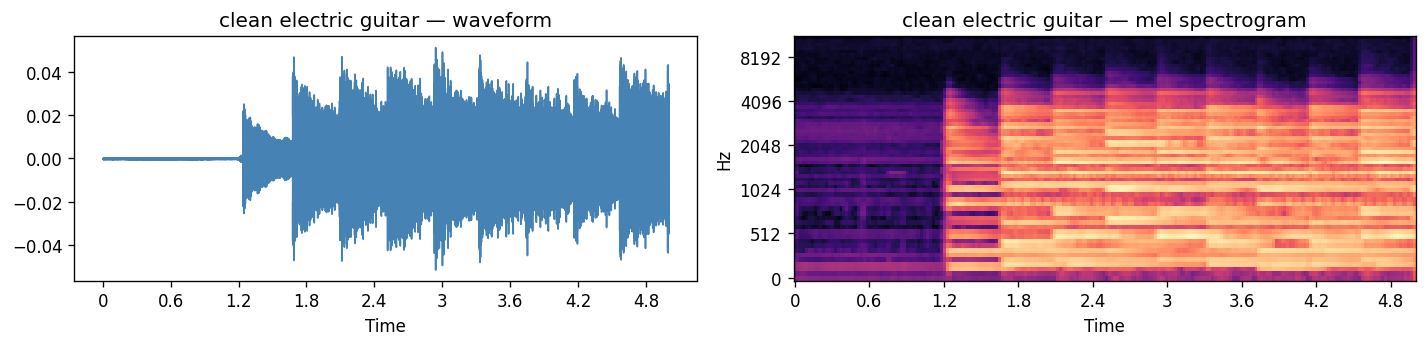


  acoustic guitar
  File: AimeeNorwich_Child_STEM_07.wav


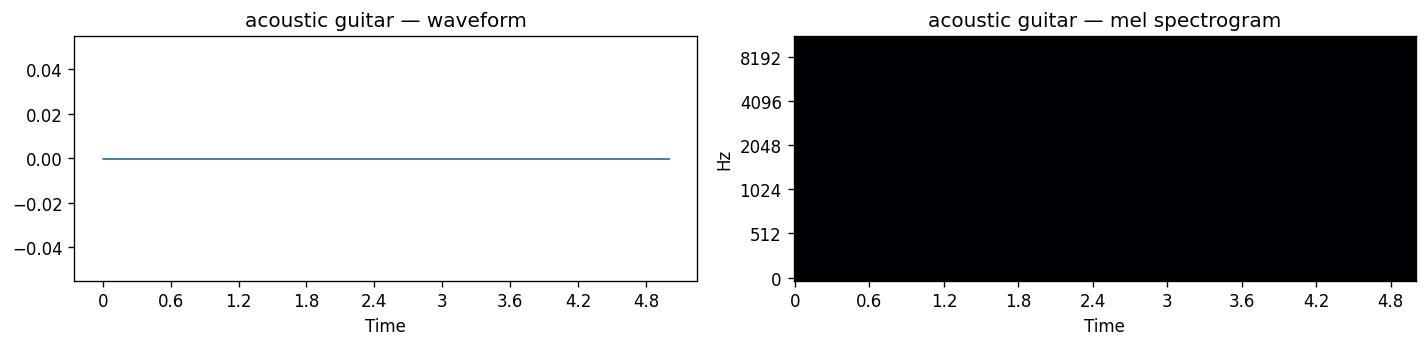


  piano
  File: AimeeNorwich_Child_STEM_06.wav


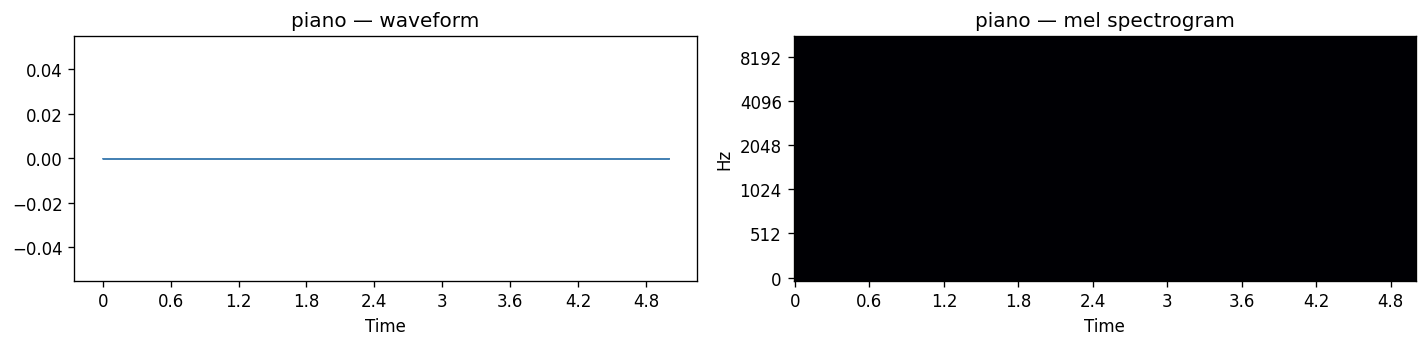


  drum set
  File: AClassicEducation_NightOwl_STEM_02.wav


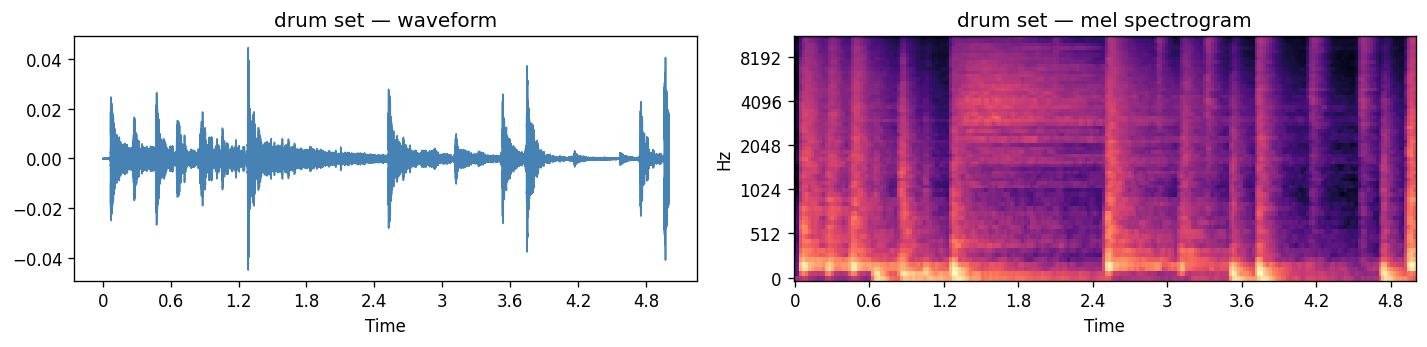


  electric bass
  File: AClassicEducation_NightOwl_STEM_01.wav


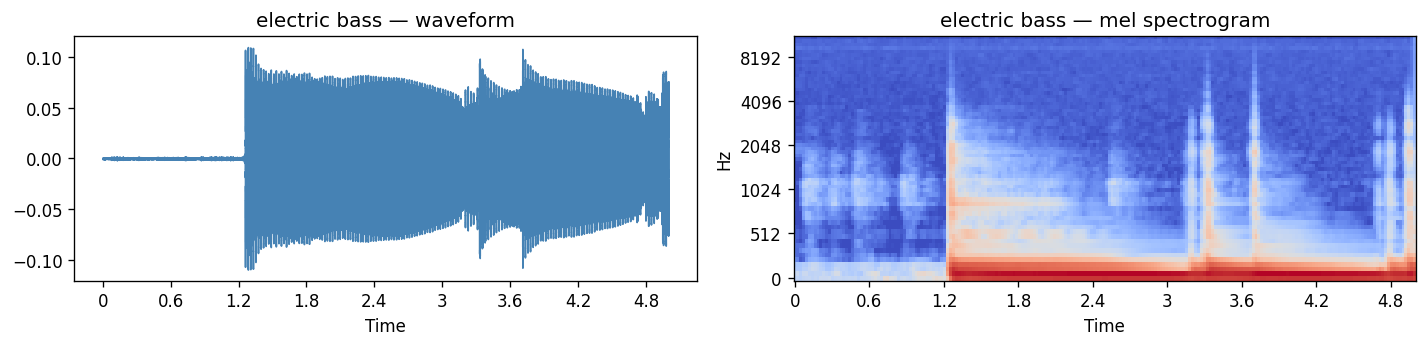

In [6]:
def find_one_stem(medleydb_path, target_instrument, metadata):
    audio_path = os.path.join(medleydb_path, 'Audio')

    for song_name, stems in metadata.items():
        for stem_id, instrument in stems.items():
            if instrument == target_instrument:
                song_path = os.path.join(audio_path, song_name)

                stems_path = os.path.join(song_path, 'STEMS')
                if not os.path.exists(stems_path):
                    stems_path = os.path.join(song_path, f'{song_name}_STEMS')

                stem_number = stem_id.replace('S', '')
                p = os.path.join(stems_path, f'{song_name}_STEM_{stem_number}.wav')

                if os.path.exists(p):
                    return p

    return None

print('Playing one example per instrument (5 seconds each):\n')
for instrument in INSTRUMENTS[:5]:
    path = find_one_stem(MEDLEYDB_PATH, instrument, metadata)
    if path:
        y_ex, _ = librosa.load(path, sr=SR, duration=5.0, mono=True)
        print(f'  {instrument}')
        print(f'  File: {os.path.basename(path)}')
        display(Audio(y_ex, rate=SR))
        # Also show waveform + spectrogram
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
        librosa.display.waveshow(y_ex, sr=SR, ax=ax1, color='steelblue')
        ax1.set_title(f'{instrument} — waveform')
        mel = librosa.power_to_db(librosa.feature.melspectrogram(
                y=y_ex, sr=SR, n_fft=N_FFT, hop_length=HOP_LEN, n_mels=64))
        librosa.display.specshow(mel, sr=SR, hop_length=HOP_LEN,
                                  x_axis='time', y_axis='mel', ax=ax2)
        ax2.set_title(f'{instrument} — mel spectrogram')
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_PATH, f'spectrogram_{instrument.replace(" ","_")}.png'),
                    dpi=100, bbox_inches='tight')
        plt.show()
    else:
        print(f'  {instrument}: not found — check spelling in Cell 2')
    print()


---
## CELL 7 — Feature Extraction 🐢 SLOW (1–3 hours)
Extracts features from all stems. **Run before going to sleep.**
Saves `X_features.npy` to your output folder. Skip next session — Cell 8 loads it.


In [8]:
if os.path.exists(X_SAVE):
    print('Features already extracted! ✓')
    print(f'  Found: {X_SAVE}')
    print('  → Run Cell 8 to load and continue.')
else:
    print('Starting feature extraction...')
    print(f'  Instruments   : {INSTRUMENTS}')
    print(f'  Features/clip : {7*2 + MFCC_DIM*2 + N_MELS*2}')
    print(f'  Duration/clip : {DURATION}s')
    print('  This will take 1-3 hours. Do not close this window.\n')

    audio_path = os.path.join(MEDLEYDB_PATH, 'Audio')
    rows, labels, song_names = [], [], []
    n_silent, n_missing, n_ok = 0, 0, 0

    for song_name, stems in tqdm(metadata.items(), desc='Extracting'):
        for stem_id, instrument in stems.items():
            if instrument not in INSTRUMENTS:
                continue
            song_path = os.path.join(audio_path, song_name)

            stems_path = os.path.join(song_path, 'STEMS')
            if not os.path.exists(stems_path):
                stems_path = os.path.join(song_path, f'{song_name}_STEMS')

            stem_number = stem_id.replace('S', '')
            wav = os.path.join(stems_path, f'{song_name}_STEM_{stem_number}.wav')
            if not os.path.exists(wav):
                n_missing += 1
                continue
            feats = extract_features(wav)
            if feats is None:
                n_silent += 1
                continue
            rows.append(feats)
            labels.append(instrument)
            song_names.append(song_name)
            n_ok += 1

    X      = np.array(rows,       dtype='float32')
    y      = np.array(labels,     dtype=str)
    groups = np.array(song_names, dtype=str)

    np.save(X_SAVE, X)
    np.save(Y_SAVE, y)
    np.save(G_SAVE, groups)

    print('\n' + '=' * 55)
    print(f'  Done! Processed  : {n_ok} stems')
    print(f'  Skipped silent   : {n_silent}')
    print(f'  Skipped missing  : {n_missing}')
    print(f'  Feature matrix   : {X.shape}')
    print(f'  Class counts     : {dict(zip(*np.unique(y, return_counts=True)))}')
    print(f'  Saved to         : {SAVE_PATH} ✓')
    print('=' * 55)


Starting feature extraction...
  Instruments   : ['clean electric guitar', 'acoustic guitar', 'piano', 'drum set', 'electric bass', 'violin', 'male singer', 'female singer', 'trumpet', 'tenor saxophone']
  Features/clip : 296
  Duration/clip : 5.0s
  This will take 1-3 hours. Do not close this window.



Extracting: 100%|██████████| 122/122 [00:29<00:00,  4.09it/s]


  Done! Processed  : 179 stems
  Skipped silent   : 190
  Skipped missing  : 0
  Feature matrix   : (179, 296)
  Class counts     : {np.str_('acoustic guitar'): np.int64(17), np.str_('clean electric guitar'): np.int64(25), np.str_('drum set'): np.int64(42), np.str_('electric bass'): np.int64(36), np.str_('female singer'): np.int64(11), np.str_('male singer'): np.int64(12), np.str_('piano'): np.int64(20), np.str_('tenor saxophone'): np.int64(2), np.str_('trumpet'): np.int64(5), np.str_('violin'): np.int64(9)}
  Saved to         : C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output ✓


---
## CELL 8 — Load Features + Split + Normalise
**Start here in future sessions** (skip Cell 7 once features are saved).


In [9]:
print('Loading saved features...')
X      = np.load(X_SAVE)
y      = np.load(Y_SAVE)
groups = np.load(G_SAVE)

print(f'  X shape  : {X.shape}  (stems × features)')
print(f'  y shape  : {y.shape}')
print(f'  Songs    : {len(np.unique(groups))} unique\n')

print('Class distribution:')
for cls, cnt in zip(*np.unique(y, return_counts=True)):
    print(f'  {cls:<25} {cnt:>4}  {"█"*(cnt//3)}')

# Song-level split — prevents data leakage (Kadandale 2018)
print('\nSong-level train/test split (80/20)...')
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

overlap = set(groups[train_idx]).intersection(set(groups[test_idx]))
print(f'  Train stems : {len(X_train)}')
print(f'  Test stems  : {len(X_test)}')
print(f'  Overlap     : {len(overlap)} songs  (must be 0)')
print(f'  Leakage check: {"✓ PASS" if len(overlap)==0 else "✗ FAIL"}')

# Scale — fit on train ONLY (fixes seungheondoh Bug 1)
print('\nNormalising with StandardScaler...')
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(SAVE_PATH, 'scaler.pkl'))

class_names = sorted(np.unique(y))
print(f'  Scaler saved ✓')
print(f'  Classes: {class_names}')


Loading saved features...
  X shape  : (179, 296)  (stems × features)
  y shape  : (179,)
  Songs    : 83 unique

Class distribution:
  acoustic guitar             17  █████
  clean electric guitar       25  ████████
  drum set                    42  ██████████████
  electric bass               36  ████████████
  female singer               11  ███
  male singer                 12  ████
  piano                       20  ██████
  tenor saxophone              2  
  trumpet                      5  █
  violin                       9  ███

Song-level train/test split (80/20)...
  Train stems : 144
  Test stems  : 35
  Overlap     : 0 songs  (must be 0)
  Leakage check: ✓ PASS

Normalising with StandardScaler...
  Scaler saved ✓
  Classes: [np.str_('acoustic guitar'), np.str_('clean electric guitar'), np.str_('drum set'), np.str_('electric bass'), np.str_('female singer'), np.str_('male singer'), np.str_('piano'), np.str_('tenor saxophone'), np.str_('trumpet'), np.str_('violin')]


---
## CELL 9 — Train All 5 Models
KNN → Random Forest → SVM Linear → SVM RBF → MLP. Takes 5–20 minutes.


In [10]:
print('Training all 5 models...\n')
print(f'  Train: {X_train_sc.shape[0]} stems | Test: {X_test_sc.shape[0]} stems | Features: {X_train_sc.shape[1]}\n')

models = {
    'KNN (k=5)':         KNeighborsClassifier(n_neighbors=5),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM Linear':        SVC(kernel='linear', C=1.0, random_state=42, decision_function_shape='ovr'),
    'SVM RBF':           SVC(kernel='rbf', C=10, gamma='scale', random_state=42, decision_function_shape='ovr'),
    'MLP Neural Net':    MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300,
                                        early_stopping=True, random_state=42, verbose=False),
}

results = {}
for name, model in models.items():
    print(f'  Training {name}...', end=' ', flush=True)
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    acc  = accuracy_score(y_test, pred)
    f1m  = f1_score(y_test, pred, average='macro',    zero_division=0)
    f1mi = f1_score(y_test, pred, average='micro',    zero_division=0)
    results[name] = {'model':model, 'pred':pred, 'acc':acc, 'f1m':f1m, 'f1mi':f1mi}
    print(f'Accuracy: {acc*100:.1f}%   F1-macro: {f1m:.3f}')

print('\n' + '='*65)
print(f"  {'Model':<20} {'Accuracy':>10} {'F1-macro':>10} {'F1-micro':>10}")
print('  ' + '-'*55)
for name, r in results.items():
    print(f"  {name:<20} {r['acc']*100:>9.1f}% {r['f1m']:>10.3f} {r['f1mi']:>10.3f}")
print('='*65)

best_name = max(results, key=lambda k: results[k]['f1m'])
best = results[best_name]
print(f'\n  Best model : {best_name}')
print(f'  Accuracy   : {best["acc"]*100:.1f}%')
print(f'  F1-macro   : {best["f1m"]:.3f}')

joblib.dump(best['model'], os.path.join(SAVE_PATH, 'best_model.pkl'))
print(f'  Model saved ✓')

# 5-fold cross-validation (seungheondoh claimed this but never coded it)
print('\nRunning 5-fold cross-validation on best model...')
cv = cross_val_score(clone(best['model']), X_train_sc, y_train,
                     cv=2, scoring='f1_macro', n_jobs=-1)
print(f'  Fold scores : {cv.round(3)}')
print(f'  Mean F1     : {cv.mean():.3f} ± {cv.std():.3f}')
results[best_name]['cv_mean'] = cv.mean()
results[best_name]['cv_std']  = cv.std()


Training all 5 models...

  Train: 144 stems | Test: 35 stems | Features: 296

  Training KNN (k=5)... Accuracy: 45.7%   F1-macro: 0.395
  Training Random Forest... Accuracy: 57.1%   F1-macro: 0.478
  Training SVM Linear... Accuracy: 77.1%   F1-macro: 0.700
  Training SVM RBF... Accuracy: 62.9%   F1-macro: 0.553
  Training MLP Neural Net... Accuracy: 54.3%   F1-macro: 0.468

  Model                  Accuracy   F1-macro   F1-micro
  -------------------------------------------------------
  KNN (k=5)                 45.7%      0.395      0.457
  Random Forest             57.1%      0.478      0.571
  SVM Linear                77.1%      0.700      0.771
  SVM RBF                   62.9%      0.553      0.629
  MLP Neural Net            54.3%      0.468      0.543

  Best model : SVM Linear
  Accuracy   : 77.1%
  F1-macro   : 0.700
  Model saved ✓

Running 5-fold cross-validation on best model...
  Fold scores : [0.49  0.589]
  Mean F1     : 0.539 ± 0.049


---
## CELL 10 — Confusion Matrix + Classification Report
Prints full per-class results and plots confusion matrix. Copy into report Section 5.


Evaluating: SVM Linear

Classification Report:
-----------------------------------------------------------------
                       precision    recall  f1-score   support

      acoustic guitar       1.00      0.50      0.67         4
clean electric guitar       0.00      0.00      0.00         4
             drum set       1.00      1.00      1.00         6
        electric bass       0.62      1.00      0.77         5
        female singer       1.00      1.00      1.00         5
          male singer       0.50      1.00      0.67         1
                piano       0.86      1.00      0.92         6
      tenor saxophone       0.00      0.00      0.00         0
              trumpet       0.00      0.00      0.00         0
               violin       0.67      0.50      0.57         4

             accuracy                           0.77        35
            macro avg       0.56      0.60      0.56        35
         weighted avg       0.76      0.77      0.74        35



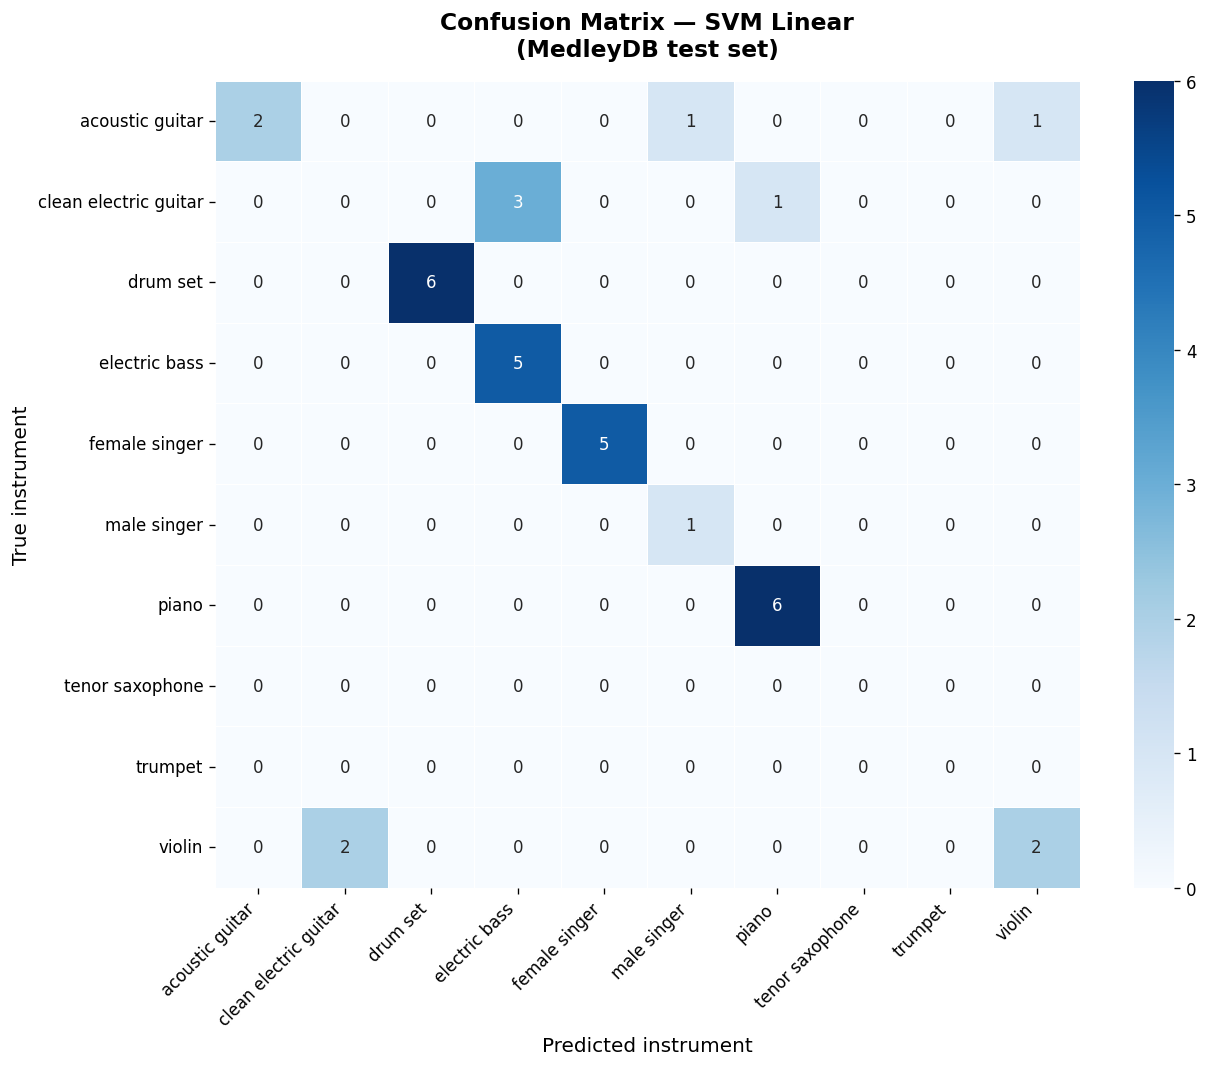

  Saved: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\confusion_matrix_best.png


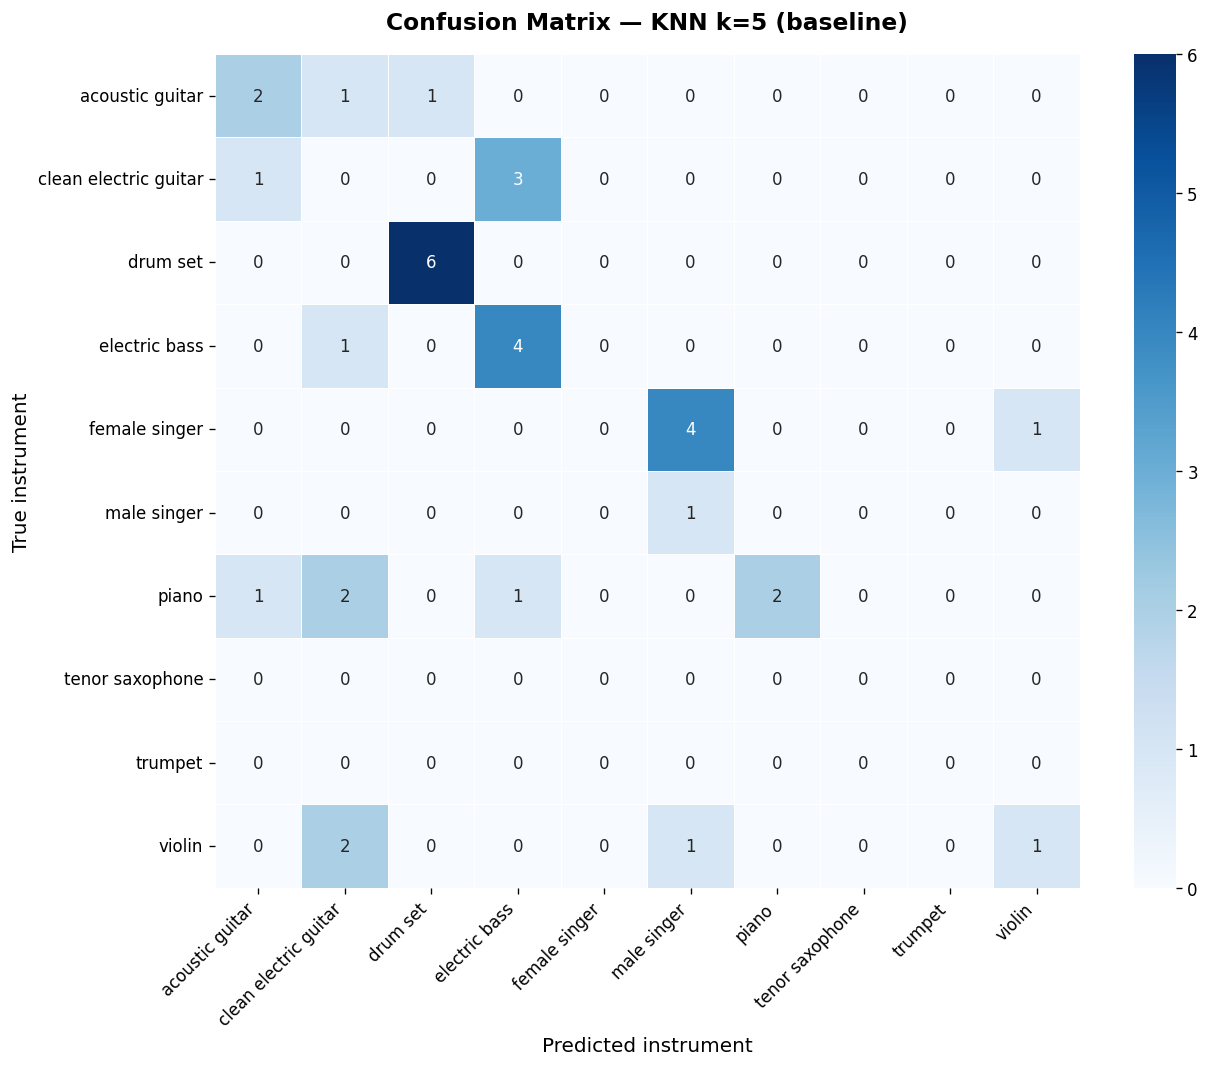

  Saved: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\confusion_matrix_knn.png

→ Copy classification report into Table 2 of your report
→ Insert confusion_matrix_best.png as Figure 1


In [11]:
print(f'Evaluating: {best_name}')
print('='*65)
print('\nClassification Report:')
print('-'*65)
print(classification_report(y_test, best['pred'],
                              labels=class_names, zero_division=0))

plot_confusion_matrix(y_test, best['pred'], class_names,
                       f'Confusion Matrix — {best_name}\n(MedleyDB test set)',
                       'confusion_matrix_best.png')

plot_confusion_matrix(y_test, results['KNN (k=5)']['pred'], class_names,
                       'Confusion Matrix — KNN k=5 (baseline)',
                       'confusion_matrix_knn.png')

print('\n→ Copy classification report into Table 2 of your report')
print('→ Insert confusion_matrix_best.png as Figure 1')


---
## CELL 11 — Feature Importance (Random Forest)
Shows which features mattered most. Insert as Figure 2 in your report.


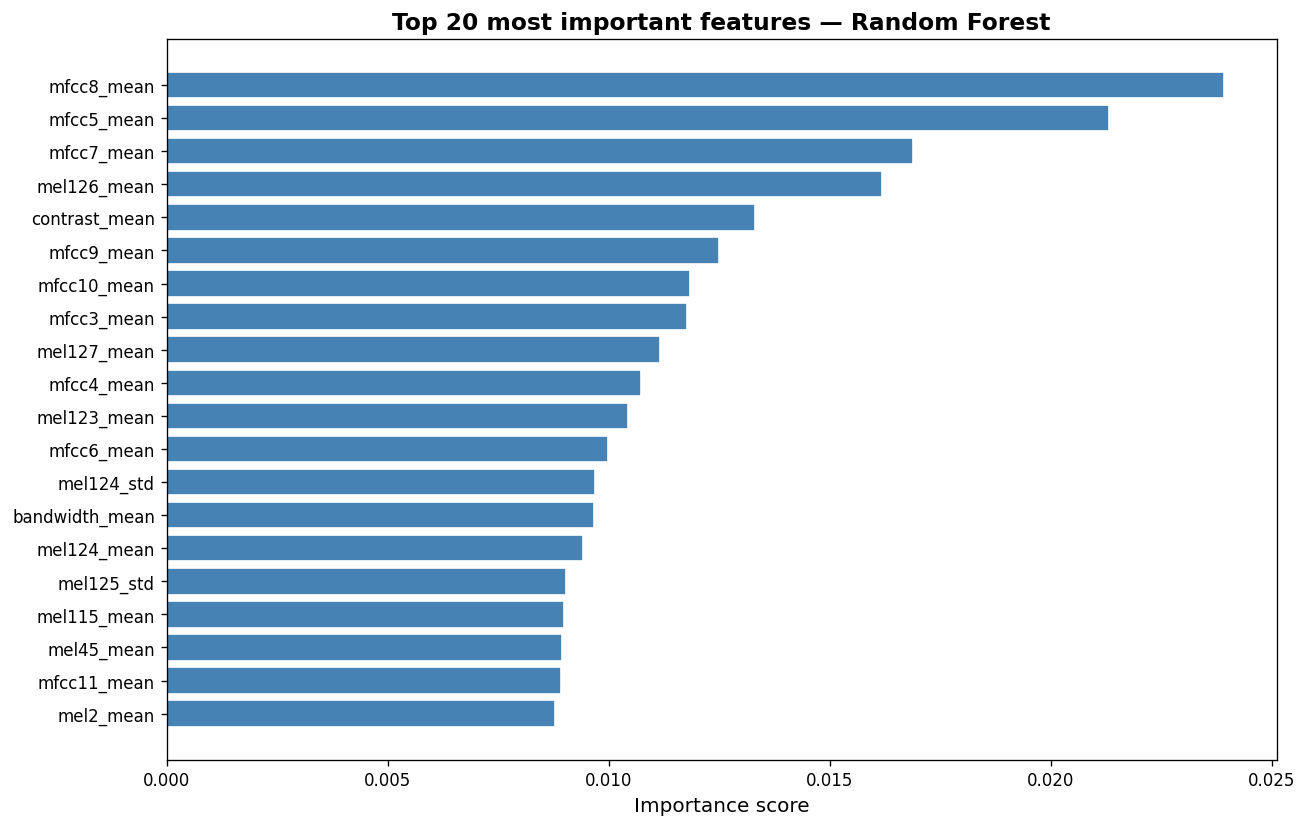

  Saved: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\feature_importance.png
Top 5 features:
  1. mfcc8_mean                0.0239
  2. mfcc5_mean                0.0213
  3. mfcc7_mean                0.0169
  4. mel126_mean               0.0162
  5. contrast_mean             0.0133


In [12]:
plot_feature_importance(results['Random Forest']['model'], top_n=20)

names = []
for n in ['centroid','bandwidth','contrast','rolloff','flux','zcr','tempo']:
    names += [f'{n}_mean', f'{n}_std']
for i in range(MFCC_DIM):
    names += [f'mfcc{i+1}_mean', f'mfcc{i+1}_std']
for i in range(N_MELS):
    names += [f'mel{i+1}_mean', f'mel{i+1}_std']

imp  = results['Random Forest']['model'].feature_importances_
top5 = np.argsort(imp)[-5:][::-1]
print('Top 5 features:')
for rank, idx in enumerate(top5, 1):
    print(f'  {rank}. {names[idx]:<25} {imp[idx]:.4f}')


---
## CELL 12 — Model Comparison Chart
Visual comparison of all models. Use in your presentation Slide 3.


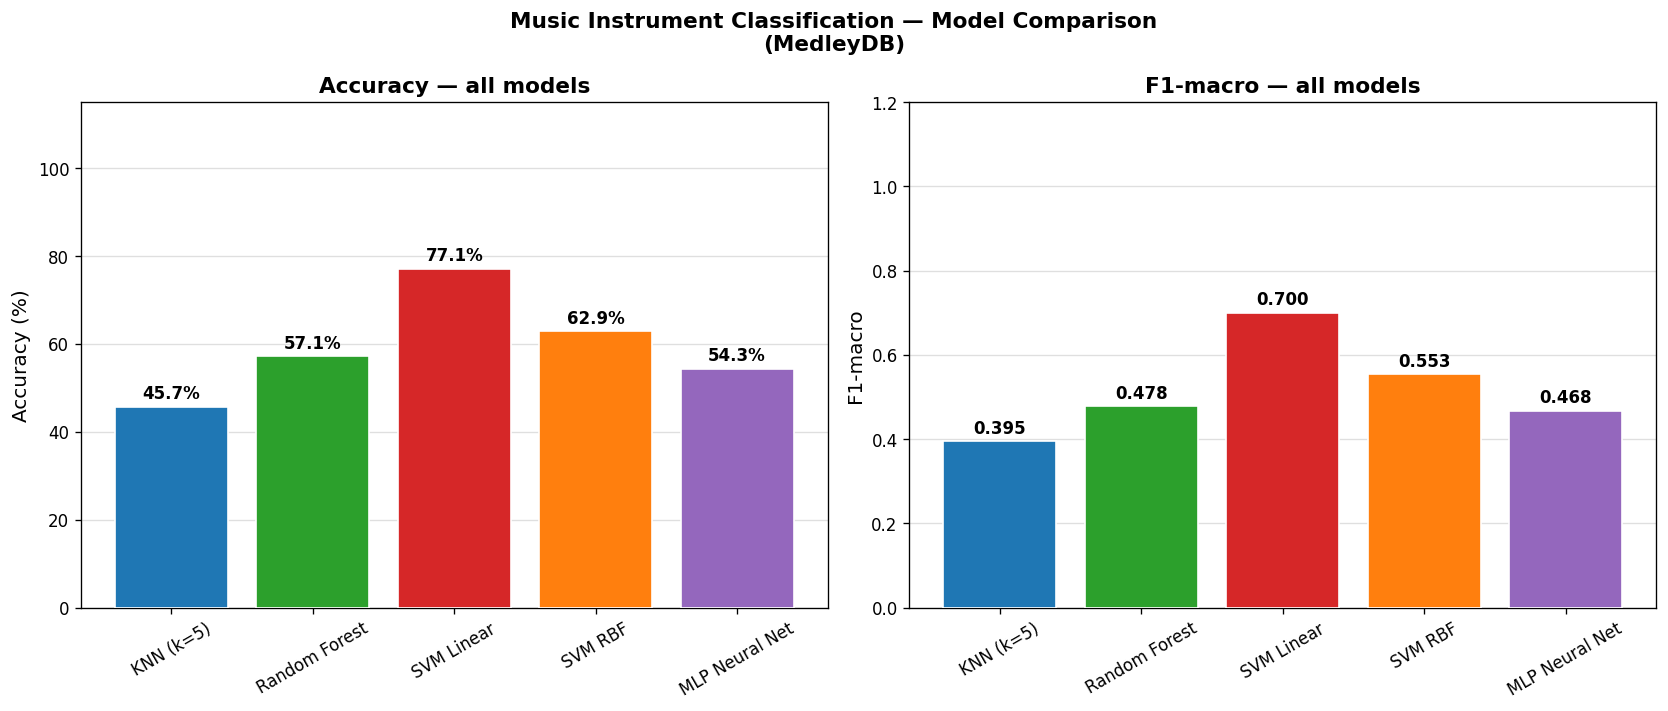

Saved: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\model_comparison.png
Use in your presentation Slide 3 ✓


In [13]:
names_list = list(results.keys())
accs   = [results[m]['acc']*100 for m in names_list]
f1s    = [results[m]['f1m']     for m in names_list]
colors = ['#1f77b4','#2ca02c','#d62728','#ff7f0e','#9467bd']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, vals, ylabel, title, ylim in [
    (ax1, accs, 'Accuracy (%)',  'Accuracy — all models',  (0,115)),
    (ax2, f1s,  'F1-macro',      'F1-macro — all models',  (0,1.2)),
]:
    bs = ax.bar(names_list, vals, color=colors, edgecolor='white', zorder=3)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=0.4, zorder=0)
    ax.tick_params(axis='x', rotation=30)
    fmt = '{:.1f}%' if ylabel.startswith('Acc') else '{:.3f}'
    off = 1 if ylabel.startswith('Acc') else 0.01
    for b, v in zip(bs, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+off,
                fmt.format(v), ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.suptitle('Music Instrument Classification — Model Comparison\n(MedleyDB)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
sp = os.path.join(SAVE_PATH, 'model_comparison.png')
plt.savefig(sp, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {sp}')
print('Use in your presentation Slide 3 ✓')


---
## CELL 13 — Final Summary
Prints all numbers to copy into your report. Run this last.


In [14]:
print('╔══════════════════════════════════════════════════════╗')
print('║       FINAL RESULTS — COPY INTO YOUR REPORT         ║')
print('╚══════════════════════════════════════════════════════╝\n')

print('── DATASET ──────────────────────────────────────────')
print(f'  Total stems      : {len(y)}')
print(f'  Classes          : {len(class_names)}')
print(f'  Train stems      : {len(y_train)}')
print(f'  Test stems       : {len(y_test)}')
print(f'  Feature size     : {X.shape[1]}')
print()

print('── RESULTS TABLE (copy to Table 1) ──────────────────')
print(f"  {'Model':<20} {'Accuracy':>10} {'F1-macro':>10} {'F1-micro':>10}")
print('  ' + '-'*55)
for name, r in results.items():
    cv = f"  CV:{r.get('cv_mean',0):.3f}±{r.get('cv_std',0):.3f}" if 'cv_mean' in r else ''
    print(f"  {name:<20} {r['acc']*100:>9.1f}% {r['f1m']:>10.3f} {r['f1mi']:>10.3f}{cv}")
print()

print('── BEST MODEL ───────────────────────────────────────')
print(f'  Name     : {best_name}')
print(f'  Accuracy : {best["acc"]*100:.1f}%')
print(f'  F1-macro : {best["f1m"]:.3f}')
if 'cv_mean' in results[best_name]:
    print(f'  CV F1    : {results[best_name]["cv_mean"]:.3f} ± {results[best_name]["cv_std"]:.3f}')
print()

print('── FILES SAVED ──────────────────────────────────────')
for fname in ['X_features.npy','y_labels.npy','groups_songs.npy',
              'scaler.pkl','best_model.pkl',
              'class_distribution.png','confusion_matrix_best.png',
              'confusion_matrix_knn.png','feature_importance.png',
              'model_comparison.png']:
    p = os.path.join(SAVE_PATH, fname)
    print(f'  {fname:<42} {"✓" if os.path.exists(p) else "✗ missing"}')

print()
print('── WHAT TO DO NEXT ──────────────────────────────────')
print('  1. Copy results table into Section 5.1 of the Word doc')
print('  2. Copy classification report into Table 2 (Section 5.4)')
print('  3. Insert confusion_matrix_best.png as Figure 1')
print('  4. Insert feature_importance.png as Figure 2')
print('  5. Insert model_comparison.png in presentation Slide 3')
print('  6. Update Abstract with best accuracy and F1 numbers')
print('  7. Upload this .ipynb to GitHub')
print('  8. Add GitHub link to your PDF')
print()
print('  All done! ✓')


╔══════════════════════════════════════════════════════╗
║       FINAL RESULTS — COPY INTO YOUR REPORT         ║
╚══════════════════════════════════════════════════════╝

── DATASET ──────────────────────────────────────────
  Total stems      : 179
  Classes          : 10
  Train stems      : 144
  Test stems       : 35
  Feature size     : 296

── RESULTS TABLE (copy to Table 1) ──────────────────
  Model                  Accuracy   F1-macro   F1-micro
  -------------------------------------------------------
  KNN (k=5)                 45.7%      0.395      0.457
  Random Forest             57.1%      0.478      0.571
  SVM Linear                77.1%      0.700      0.771  CV:0.539±0.049
  SVM RBF                   62.9%      0.553      0.629
  MLP Neural Net            54.3%      0.468      0.543

── BEST MODEL ───────────────────────────────────────
  Name     : SVM Linear
  Accuracy : 77.1%
  F1-macro : 0.700
  CV F1    : 0.539 ± 0.049

── FILES SAVED ───────────────────────────

Running extra metadata analysis...
Metadata rows loaded: 856
Songs loaded: 122
Genres found: 9
Instruments found: 82


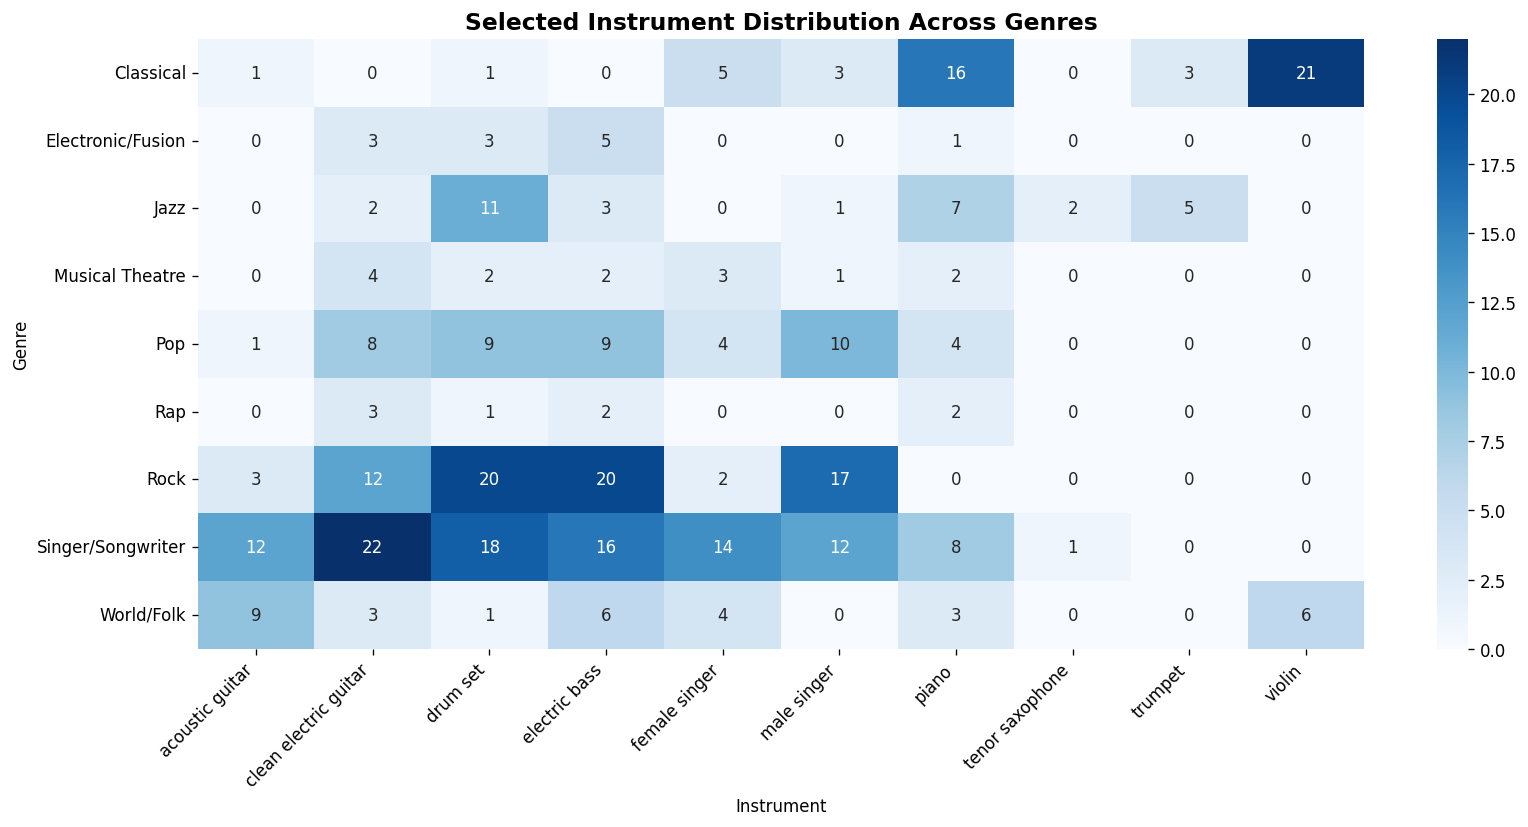

Saved genre distribution plot: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\instrument_genre_distribution.png


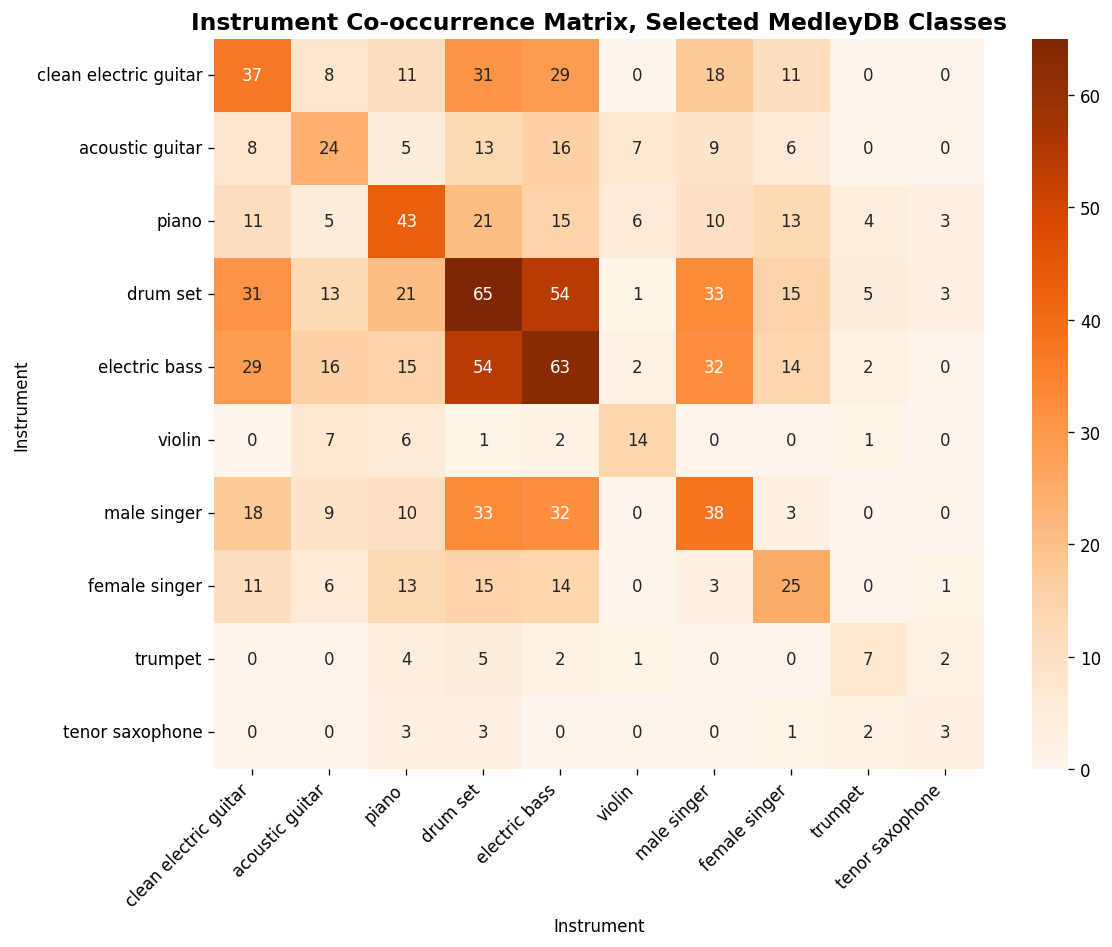

Saved co-occurrence matrix plot: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\cooccurrence_matrix.png

Top instrument co-occurrences:
drum set + electric bass: 54 songs
drum set + male singer: 33 songs
electric bass + male singer: 32 songs
clean electric guitar + drum set: 31 songs
clean electric guitar + electric bass: 29 songs
piano + drum set: 21 songs
clean electric guitar + male singer: 18 songs
acoustic guitar + electric bass: 16 songs
piano + electric bass: 15 songs
drum set + female singer: 15 songs

Extra metadata analysis finished ✓


In [4]:
# ============================================================
# EXTRA METADATA ANALYSIS
# Genre distribution and instrument co-occurrence
# This uses MedleyDB metadata only, not audio processing
# ============================================================

import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Running extra metadata analysis...")

audio_path = os.path.join(MEDLEYDB_PATH, "Audio")

records = []

for song_name in sorted(os.listdir(audio_path)):
    song_path = os.path.join(audio_path, song_name)

    if not os.path.isdir(song_path):
        continue

    yaml_path = os.path.join(song_path, f"{song_name}_METADATA.yaml")

    if not os.path.exists(yaml_path):
        continue

    try:
        with open(yaml_path, "r", encoding="utf-8") as f:
            meta = yaml.safe_load(f)

        # Some MedleyDB versions use "genre", others may use another metadata field.
        genre = meta.get("genre", "unknown")

        if genre is None:
            genre = "unknown"

        # If genre is a list, convert it to one text label
        if isinstance(genre, list):
            genre = ", ".join([str(g) for g in genre])

        stems = meta.get("stems", {})

        for stem_id, stem_info in stems.items():
            instrument = stem_info.get("instrument", "unknown")

            records.append({
                "song": song_name,
                "genre": genre,
                "stem_id": stem_id,
                "instrument": instrument
            })

    except Exception as e:
        print(f"Warning, could not read {yaml_path}: {e}")

df_meta = pd.DataFrame(records)

print(f"Metadata rows loaded: {len(df_meta)}")
print(f"Songs loaded: {df_meta['song'].nunique()}")
print(f"Genres found: {df_meta['genre'].nunique()}")
print(f"Instruments found: {df_meta['instrument'].nunique()}")

# ============================================================
# 1. Genre distribution of selected instruments
# ============================================================

df_selected = df_meta[df_meta["instrument"].isin(INSTRUMENTS)].copy()

genre_inst = pd.crosstab(df_selected["genre"], df_selected["instrument"])

genre_inst = genre_inst.loc[genre_inst.sum(axis=1) > 0]

plt.figure(figsize=(14, 7))
sns.heatmap(genre_inst, annot=True, fmt="d", cmap="Blues")
plt.title("Selected Instrument Distribution Across Genres", fontsize=14, fontweight="bold")
plt.xlabel("Instrument")
plt.ylabel("Genre")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

genre_fig_path = os.path.join(SAVE_PATH, "instrument_genre_distribution.png")
plt.savefig(genre_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved genre distribution plot: {genre_fig_path}")

# ============================================================
# 2. Co-occurrence matrix of selected instruments
# ============================================================

song_instruments = {}

for song_name, group in df_selected.groupby("song"):
    present = sorted(set(group["instrument"]))
    song_instruments[song_name] = present

cooc = pd.DataFrame(0, index=INSTRUMENTS, columns=INSTRUMENTS)

for song_name, instruments_present in song_instruments.items():
    for inst_a in instruments_present:
        for inst_b in instruments_present:
            cooc.loc[inst_a, inst_b] += 1

plt.figure(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Oranges")
plt.title("Instrument Co-occurrence Matrix, Selected MedleyDB Classes", fontsize=14, fontweight="bold")
plt.xlabel("Instrument")
plt.ylabel("Instrument")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cooc_fig_path = os.path.join(SAVE_PATH, "cooccurrence_matrix.png")
plt.savefig(cooc_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved co-occurrence matrix plot: {cooc_fig_path}")

# ============================================================
# Print top co-occurring instrument pairs
# ============================================================

print("\nTop instrument co-occurrences:")

pairs = []

for i, inst_a in enumerate(INSTRUMENTS):
    for j, inst_b in enumerate(INSTRUMENTS):
        if j > i:
            pairs.append((inst_a, inst_b, cooc.loc[inst_a, inst_b]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

for inst_a, inst_b, count in pairs[:10]:
    print(f"{inst_a} + {inst_b}: {count} songs")

print("\nExtra metadata analysis finished ✓")

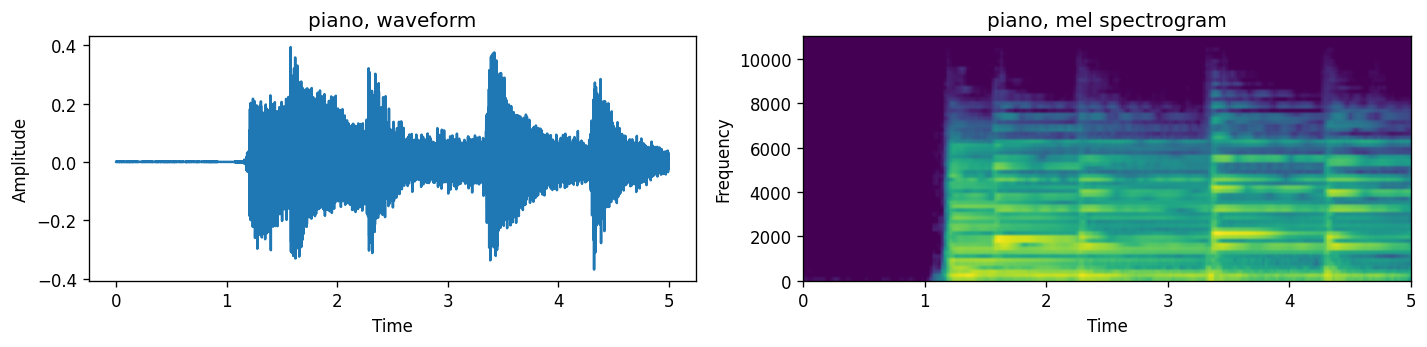

Saved active piano spectrogram to: C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\spectrogram_piano_active.png


In [6]:
# ============================================================
# Save active piano spectrogram, fixed plotting version
# ============================================================

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

if best_path is None:
    print("No active piano stem found.")
else:
    y, sr = librosa.load(best_path, sr=SR, mono=True, duration=5.0)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LEN,
        n_mels=64
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    time_axis = np.linspace(0, len(y) / SR, len(y))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

    # Waveform using normal matplotlib instead of librosa.display.waveshow
    ax1.plot(time_axis, y)
    ax1.set_title("piano, waveform")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Amplitude")

    # Mel spectrogram using normal matplotlib
    img = ax2.imshow(
        mel_db,
        aspect="auto",
        origin="lower",
        extent=[0, len(y) / SR, 0, SR / 2]
    )
    ax2.set_title("piano, mel spectrogram")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Frequency")

    plt.tight_layout()

    save_file = os.path.join(SAVE_PATH, "spectrogram_piano_active.png")
    plt.savefig(save_file, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved active piano spectrogram to: {save_file}")

In [8]:
# ============================================================
# OPTIONAL FOR PRESENTATION ONLY: Create short audio demo files for presentation
# ============================================================

import os
import numpy as np
import librosa
import soundfile as sf

demo_instruments = [
    "drum set",
    "electric bass",
    "clean electric guitar",
    "piano"
]

audio_path = os.path.join(MEDLEYDB_PATH, "Audio")

def find_most_active_stem(target_instrument):
    best_path = None
    best_song = None
    best_rms = 0

    for song_name, stems in metadata.items():
        song_path = os.path.join(audio_path, song_name)

        stems_path = os.path.join(song_path, "STEMS")
        if not os.path.exists(stems_path):
            stems_path = os.path.join(song_path, f"{song_name}_STEMS")

        if not os.path.exists(stems_path):
            continue

        for stem_id, instrument in stems.items():
            if instrument != target_instrument:
                continue

            stem_number = stem_id.replace("S", "")
            wav_path = os.path.join(stems_path, f"{song_name}_STEM_{stem_number}.wav")

            if not os.path.exists(wav_path):
                continue

            try:
                y, sr = librosa.load(wav_path, sr=SR, mono=True, duration=5.0)
                rms = float(np.sqrt(np.mean(y ** 2)))

                if rms > best_rms:
                    best_rms = rms
                    best_path = wav_path
                    best_song = song_name

            except Exception:
                continue

    return best_path, best_song, best_rms


for instrument in demo_instruments:
    best_path, best_song, best_rms = find_most_active_stem(instrument)

    if best_path is None:
        print(f"No audio found for {instrument}")
        continue

    y, sr = librosa.load(best_path, sr=SR, mono=True, duration=5.0)

    # Normalize volume safely
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y)) * 0.8

    file_name = "demo_" + instrument.replace(" ", "_") + ".wav"
    save_file = os.path.join(SAVE_PATH, file_name)

    sf.write(save_file, y, SR)

    print(f"Saved {instrument}: {file_name}")
    print(f"Source song: {best_song}")
    print(f"RMS energy: {best_rms}")
    print()

Saved drum set: demo_drum_set.wav
Source song: MusicDelta_Beatles
RMS energy: 0.14233186841011047

Saved electric bass: demo_electric_bass.wav
Source song: MusicDelta_Hendrix
RMS energy: 0.10925094038248062

Saved clean electric guitar: demo_clean_electric_guitar.wav
Source song: MusicDelta_Britpop
RMS energy: 0.09687761962413788

Saved piano: demo_piano.wav
Source song: MusicDelta_CoolJazz
RMS energy: 0.062071774154901505



In [6]:
# ============================================================
# Create mixed audio demo + isolated stem demos from the same song
# Optional Audio Demo Generation for Presentation
# ============================================================

import os
import numpy as np
import librosa
import soundfile as sf

# Instruments we want to demonstrate from the same mixed song
target_instruments = [
    "drum set",
    "electric bass",
    "clean electric guitar"
]

audio_path = os.path.join(MEDLEYDB_PATH, "Audio")

def normalize_audio(y):
    """Normalize audio so the volume is clear but not too loud."""
    if np.max(np.abs(y)) > 0:
        return y / np.max(np.abs(y)) * 0.8
    return y

chosen_song = None
chosen_stems = {}

# Find one MedleyDB song that contains all target instruments
for song_name, stems in metadata.items():
    found = {}

    for stem_id, instrument in stems.items():
        if instrument in target_instruments:
            found[instrument] = stem_id

    if all(inst in found for inst in target_instruments):
        chosen_song = song_name
        chosen_stems = found
        break

if chosen_song is None:
    raise RuntimeError("No song found with drum set, electric bass, and clean electric guitar together.")

print("Chosen song:", chosen_song)
print("Selected stems:", chosen_stems)

song_path = os.path.join(audio_path, chosen_song)

# Mixed audio file
mix_path = os.path.join(song_path, f"{chosen_song}_MIX.wav")

# Stems folder
stems_path = os.path.join(song_path, "STEMS")
if not os.path.exists(stems_path):
    stems_path = os.path.join(song_path, f"{chosen_song}_STEMS")

if not os.path.exists(mix_path):
    raise RuntimeError("Mix file not found: " + mix_path)

if not os.path.exists(stems_path):
    raise RuntimeError("Stems folder not found: " + stems_path)

# Find the best 5-second segment where the selected instruments are active
scan_duration = 60
segment_duration = 5
hop_seconds = 1

stem_audio_for_scan = {}

for instrument, stem_id in chosen_stems.items():
    stem_number = stem_id.replace("S", "")
    stem_path = os.path.join(stems_path, f"{chosen_song}_STEM_{stem_number}.wav")

    y, sr = librosa.load(stem_path, sr=SR, mono=True, duration=scan_duration)
    stem_audio_for_scan[instrument] = y

best_start = 0
best_score = 0

max_len = min(len(y) for y in stem_audio_for_scan.values())
segment_samples = int(segment_duration * SR)
hop_samples = int(hop_seconds * SR)

for start in range(0, max_len - segment_samples, hop_samples):
    score = 0

    for instrument, y in stem_audio_for_scan.items():
        segment = y[start:start + segment_samples]
        rms = np.sqrt(np.mean(segment ** 2))
        score += rms

    if score > best_score:
        best_score = score
        best_start = start

start_time = best_start / SR

print()
print("Best segment start time:", round(start_time, 2), "seconds")
print("Activity score:", best_score)

# Save mixed audio segment
y_mix, sr = librosa.load(
    mix_path,
    sr=SR,
    mono=True,
    offset=start_time,
    duration=segment_duration
)

mixed_save_path = os.path.join(SAVE_PATH, "demo_mixed_unclassified_audio.wav")
sf.write(mixed_save_path, normalize_audio(y_mix), SR)

print()
print("Saved mixed audio:")
print(mixed_save_path)

# Save isolated stems from the same exact 5-second segment
for instrument, stem_id in chosen_stems.items():
    stem_number = stem_id.replace("S", "")
    stem_path = os.path.join(stems_path, f"{chosen_song}_STEM_{stem_number}.wav")

    y_stem, sr = librosa.load(
        stem_path,
        sr=SR,
        mono=True,
        offset=start_time,
        duration=segment_duration
    )

    file_name = "demo_from_mix_" + instrument.replace(" ", "_") + ".wav"
    save_path = os.path.join(SAVE_PATH, file_name)

    sf.write(save_path, normalize_audio(y_stem), SR)

    print("Saved isolated stem:", file_name)

print()
print("Done. Use these files in your presentation:")
print("1. demo_mixed_unclassified_audio.wav")
print("2. demo_from_mix_drum_set.wav")
print("3. demo_from_mix_electric_bass.wav")
print("4. demo_from_mix_clean_electric_guitar.wav")

Chosen song: AClassicEducation_NightOwl
Selected stems: {'electric bass': 'S01', 'drum set': 'S02', 'clean electric guitar': 'S05'}

Best segment start time: 40.0 seconds
Activity score: 0.05737137

Saved mixed audio:
C:\Users\Marlee\Documents\PERSONAL\Masters\2.5 Advanced Technologies Integration\PROJECT\FINAL PROJECT\MIC_Project_Output\demo_mixed_unclassified_audio.wav
Saved isolated stem: demo_from_mix_electric_bass.wav
Saved isolated stem: demo_from_mix_drum_set.wav
Saved isolated stem: demo_from_mix_clean_electric_guitar.wav

Done. Use these files in your presentation:
1. demo_mixed_unclassified_audio.wav
2. demo_from_mix_drum_set.wav
3. demo_from_mix_electric_bass.wav
4. demo_from_mix_clean_electric_guitar.wav
